In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
import nltk
import re
from IPython.display import display
import streamlit as st


In [16]:
!pip install wordcloud

   ---------------------------------------- 0.0/301.2 kB ? eta -:--:--
   -- ------------------------------------ 20.5/301.2 kB 640.0 kB/s eta 0:00:01
   ----- --------------------------------- 41.0/301.2 kB 487.6 kB/s eta 0:00:01
   -------------- ----------------------- 112.6/301.2 kB 819.2 kB/s eta 0:00:01
   ------------------- ------------------ 153.6/301.2 kB 913.1 kB/s eta 0:00:01
   ------------------------------- -------- 235.5/301.2 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 301.2/301.2 kB 1.1 MB/s eta 0:00:00


In [3]:
df = pd.read_csv("gdelt_cleaned_with_text.csv")

In [4]:
df.head()

,SQLDATE,Actor1Name,Actor2Name,EventRootCode,AvgTone,GoldsteinScale,SOURCEURL,title,content
0,2024-09-04,Unknown,UNITED STATES,19,-9.555345,-10.0,http://dagblog.com/link/crime-news-cdc-info-sh...,[CRIME News] CDC info. shows spike in homicide...,According to the CDC the US had a homicide tot...
1,2024-09-01,CALIF,RESIDENTS,19,-8.333333,-10.0,http://southtahoenow.com/story/08/31/2024/two-...,"Two men hospitalized after they fought, allege...","SOUTH LAKE TAHOE, Calif. – Two South Lake Taho..."
2,2024-10-26,GAZA,ISRAEL,19,-6.474820,-10.0,http://usa.chinadaily.com.cn/a/202411/02/WS672...,UN investigative report details violence in Gaza,Palestinians organize a demonstration on Frida...
3,2024-09-06,AFRICA,COMMUNITY,18,3.157895,-10.0,http://www.africaleader.com/news/278556639/nam...,"Namibia, China mark 35 years of ties with CSR ...",Namibia and China on Thursday marked 35 years ...
4,2024-09-04,ISRAELI,WEST BANK,19,-5.263158,-10.0,http://www.em.com.br/internacional/2024/09/693...,Ministro da Defesa de Israel pede que Exército...,"O ministro da Defesa de Israel, Yoav Gallant, ..."


In [5]:

df['text'] = df['title'].fillna('') + ' ' + df['content'].fillna('')

In [6]:
df.head()

,SQLDATE,Actor1Name,Actor2Name,EventRootCode,AvgTone,GoldsteinScale,SOURCEURL,title,content,text
0,2024-09-04,Unknown,UNITED STATES,19,-9.555345,-10.0,http://dagblog.com/link/crime-news-cdc-info-sh...,[CRIME News] CDC info. shows spike in homicide...,According to the CDC the US had a homicide tot...,[CRIME News] CDC info. shows spike in homicide...
1,2024-09-01,CALIF,RESIDENTS,19,-8.333333,-10.0,http://southtahoenow.com/story/08/31/2024/two-...,"Two men hospitalized after they fought, allege...","SOUTH LAKE TAHOE, Calif. – Two South Lake Taho...","Two men hospitalized after they fought, allege..."
2,2024-10-26,GAZA,ISRAEL,19,-6.474820,-10.0,http://usa.chinadaily.com.cn/a/202411/02/WS672...,UN investigative report details violence in Gaza,Palestinians organize a demonstration on Frida...,UN investigative report details violence in Ga...
3,2024-09-06,AFRICA,COMMUNITY,18,3.157895,-10.0,http://www.africaleader.com/news/278556639/nam...,"Namibia, China mark 35 years of ties with CSR ...",Namibia and China on Thursday marked 35 years ...,"Namibia, China mark 35 years of ties with CSR ..."
4,2024-09-04,ISRAELI,WEST BANK,19,-5.263158,-10.0,http://www.em.com.br/internacional/2024/09/693...,Ministro da Defesa de Israel pede que Exército...,"O ministro da Defesa de Israel, Yoav Gallant, ...",Ministro da Defesa de Israel pede que Exército...


In [10]:
print("Tổng số bài:", len(df))
print("Khoảng thời gian:", df['SQLDATE'].min(), "–", df['SQLDATE'].max())
print("Độ dài trung bình:", df['text'].apply(len).mean())


Tổng số bài: 1184
Khoảng thời gian: 2024-09-01 – 2024-10-27
Độ dài trung bình: 3828.6342905405404


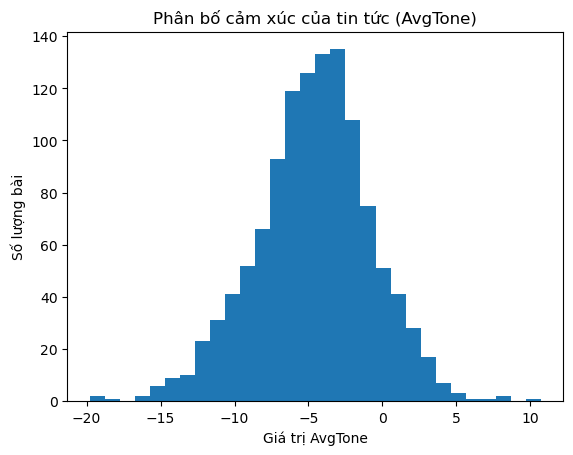

In [11]:
import matplotlib.pyplot as plt

plt.hist(df['AvgTone'], bins=30)
plt.title('Phân bố cảm xúc của tin tức (AvgTone)')
plt.xlabel('Giá trị AvgTone')
plt.ylabel('Số lượng bài')
plt.show()


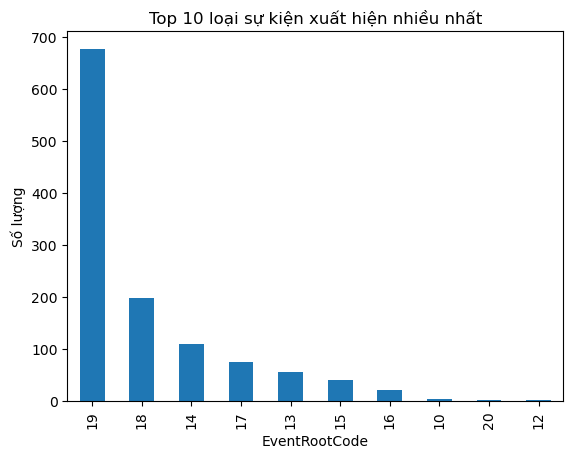

In [12]:
df['EventRootCode'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 loại sự kiện xuất hiện nhiều nhất')
plt.xlabel('EventRootCode')
plt.ylabel('Số lượng')
plt.show()


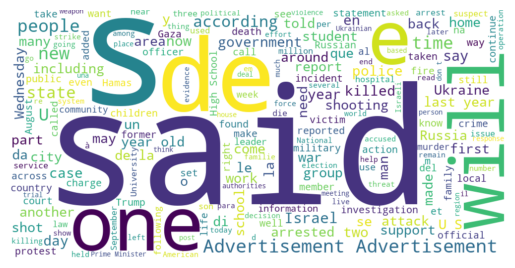

In [18]:
from wordcloud import WordCloud

text = ' '.join(df['text'])
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [19]:
tone_by_event = df.groupby('EventRootCode')['AvgTone'].mean().sort_values(ascending=False)
print(tone_by_event.head(10))


EventRootCode
12   -2.263374
15   -2.874773
14   -2.895201
20   -3.192488
13   -3.234367
16   -3.267872
19   -4.674841
17   -5.553633
18   -5.952983
10   -6.897080
Name: AvgTone, dtype: float64


In [7]:
import re

def clean_text(text):
    if isinstance(text, str):
        text = text.lower()  # chuyển về chữ thường
        text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # xóa URL
        text = re.sub(r"[^a-z\s]", " ", text)  # chỉ giữ lại ký tự chữ cái tiếng Anh
        text = re.sub(r"\s+", " ", text).strip()  # xóa khoảng trắng thừa
        return text
    else:
        return ""

# Áp dụng cho cột text hoặc content
df['clean_text'] = df['text'].apply(clean_text)



In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['clean_text'])

In [21]:
df.head()

,SQLDATE,Actor1Name,Actor2Name,EventRootCode,AvgTone,GoldsteinScale,SOURCEURL,title,content,text,clean_text
0,2024-09-04,Unknown,UNITED STATES,19,-9.555345,-10.0,http://dagblog.com/link/crime-news-cdc-info-sh...,[CRIME News] CDC info. shows spike in homicide...,According to the CDC the US had a homicide tot...,[CRIME News] CDC info. shows spike in homicide...,crime news cdc info shows spike in homicides c...
1,2024-09-01,CALIF,RESIDENTS,19,-8.333333,-10.0,http://southtahoenow.com/story/08/31/2024/two-...,"Two men hospitalized after they fought, allege...","SOUTH LAKE TAHOE, Calif. – Two South Lake Taho...","Two men hospitalized after they fought, allege...",two men hospitalized after they fought alleged...
2,2024-10-26,GAZA,ISRAEL,19,-6.474820,-10.0,http://usa.chinadaily.com.cn/a/202411/02/WS672...,UN investigative report details violence in Gaza,Palestinians organize a demonstration on Frida...,UN investigative report details violence in Ga...,un investigative report details violence in ga...
3,2024-09-06,AFRICA,COMMUNITY,18,3.157895,-10.0,http://www.africaleader.com/news/278556639/nam...,"Namibia, China mark 35 years of ties with CSR ...",Namibia and China on Thursday marked 35 years ...,"Namibia, China mark 35 years of ties with CSR ...",namibia china mark years of ties with csr repo...
4,2024-09-04,ISRAELI,WEST BANK,19,-5.263158,-10.0,http://www.em.com.br/internacional/2024/09/693...,Ministro da Defesa de Israel pede que Exército...,"O ministro da Defesa de Israel, Yoav Gallant, ...",Ministro da Defesa de Israel pede que Exército...,ministro da defesa de israel pede que ex rcito...


In [7]:
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
print(tfidf_df.head())


   aap  abandoned  abbott  abc  abducted  abdulrahimzai   ability  able  \
0  0.0        0.0     0.0  0.0       0.0            0.0  0.000000   0.0   
1  0.0        0.0     0.0  0.0       0.0            0.0  0.000000   0.0   
2  0.0        0.0     0.0  0.0       0.0            0.0  0.030202   0.0   
3  0.0        0.0     0.0  0.0       0.0            0.0  0.000000   0.0   
4  0.0        0.0     0.0  0.0       0.0            0.0  0.000000   0.0   

   abortion  abraham  ...  zona  zonas  zone  zones  zosta   zu  zum  zur  \
0       0.0      0.0  ...   0.0    0.0   0.0    0.0    0.0  0.0  0.0  0.0   
1       0.0      0.0  ...   0.0    0.0   0.0    0.0    0.0  0.0  0.0  0.0   
2       0.0      0.0  ...   0.0    0.0   0.0    0.0    0.0  0.0  0.0  0.0   
3       0.0      0.0  ...   0.0    0.0   0.0    0.0    0.0  0.0  0.0  0.0   
4       0.0      0.0  ...   0.0    0.0   0.0    0.0    0.0  0.0  0.0  0.0   

   zwei  zyn  
0   0.0  0.0  
1   0.0  0.0  
2   0.0  0.0  
3   0.0  0.0  
4   0.0  0.

In [8]:
# 2️⃣ Lấy danh sách từ khóa
feature_names = tfidf.get_feature_names_out()

# 3️⃣ Chuyển thành DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

# 4️⃣ Hàm lấy top N từ khóa của một bài
def get_top_keywords(row, feature_names, top_n=10):
    # Lấy vector của bài
    sorted_indices = row.argsort()[::-1][:top_n]  # sắp xếp giảm dần
    keywords = [(feature_names[i], row[i]) for i in sorted_indices if row[i] > 0]
    return keywords

# 5️⃣ Lưu danh sách top từ khóa cho mỗi bài vào DataFrame
df['top_keywords'] = [
    get_top_keywords(tfidf_matrix[i].toarray().flatten(), feature_names, top_n=10)
    for i in range(tfidf_matrix.shape[0])
]

# 6️⃣ In thử kết quả
for i in range(3):  # in 3 bài đầu
    print(f"\n📰 {df.loc[i, 'title']}")
    print("🔝 Top 10 từ khóa:")
    for word, score in df.loc[i, 'top_keywords']:
        print(f"   {word:<20} {score:.4f}")


📰 [CRIME News] CDC info. shows spike in homicides coinciding with riots over Geo. Floyd
🔝 Top 10 từ khóa:
   spike                0.5675
   info                 0.2591
   protesting           0.2591
   george               0.2491
   homicide             0.2304
   happening            0.2274
   compared             0.2231
   pic                  0.2134
   majority             0.1982
   shows                0.1982

📰 Two men hospitalized after they fought, allegedly stabbed each other
🔝 Top 10 từ khóa:
   lake                 0.5004
   men                  0.2812
   stabbed              0.2723
   fought               0.2589
   south                0.2575
   transported          0.2292
   details              0.1730
   hospital             0.1632
   time                 0.1601
   near                 0.1540

📰 UN investigative report details violence in Gaza
🔝 Top 10 từ khóa:
   gaza                 0.3409
   israel               0.3202
   strip                0.2546
   israeli          

In [9]:
tfidf_df.head()

,aap,abandoned,abbott,abc,abducted,abdulrahimzai,ability,able,abortion,abraham,...,zona,zonas,zone,zones,zosta,zu,zum,zur,zwei,zyn
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.030202,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
#  Tạo vector TF-IDF từ cột clean_text
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['clean_text'])

# Hàm gợi ý bài báo tương tự (hiển thị hệ số cosine)
def recommend_news(input_text, top_n=5):
# Vector hóa đoạn văn bản đầu vào
input_vec = tfidf.transform([input_text])
# Tính cosine
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
   
    
# Lấy chỉ số bài báo có độ tương đồng cao nhất
    top_indices = cosine_sim.argsort()[-top_n:][::-1]
    
# Lấy dữ liệu bài báo tương ứng
results = df.iloc[top_indices][['title', 'clean_text', 'SOURCEURL']].copy()
    
# Thêm cột hệ số tương đồng cosine
results['cosine_similarity'] = cosine_sim[top_indices]  
return results

#  Thử nghiệm
query = "China"
recommendations = recommend_news(query)
display(
    recommendations.style.background_gradient(subset=['cosine_similarity'], cmap='Blues')
                    .format({'cosine_similarity': '{:.3f}'})
)


In [3]:
# 4. Giao diện Streamlit
st.title("📰 Hệ thống gợi ý tin tức")
st.write("Nhập nội dung hoặc chủ đề bạn quan tâm:")

input_text = st.text_area("Nhập nội dung:")
if st.button("Gợi ý bài viết"):
    if input_text.strip():
        results = recommend_news(input_text)
        for i, row in results.iterrows():
            st.markdown(f"**{row['title']}**  \n🕵️ Nguồn: {row['source']}  \n🔗 [Đọc bài]({row['url']})  \n📈 Cosine: {row['similarity']:.2f}")
    else:
        st.warning("Vui lòng nhập nội dung.")

2025-11-12 22:00:57.850 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-12 22:00:58.030 
  command:

    streamlit run C:\Users\Nguyen Van Tuan\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-11-12 22:00:58.030 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-12 22:00:58.030 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-12 22:00:58.034 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-12 22:00:58.035 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-12 22:00:58.035 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-12 22:00:58.036 Thread 'MainT